In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
# Database Credentials (Replace with your own credentials)

username = "YOUR_USERNAME"
password = "YOUR_PASSWORD"
host = "YOUR_HOST"
database = "YOUR_DATABASE"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}/{database}"
)

df = pd.read_sql("SELECT * FROM auto_table", engine)

df.head()

,NAIC,Company_Name,Ratio,Upheld_Complaints,Question_of_Fact_Complaints,Not_Upheld_Complaints,Total_Complaints,Premiums_Written,Ranking,Filing_Year,FIELD11,FIELD12
0,32786,Progressive Specialty Insurance Company,0.0,0,17,29,46,204.173,1,2016,None,None
1,19976,Amica Mutual Insurance Company,0.0,0,9,8,17,84.769,2,2016,None,None
2,25453,Nationwide Insurance Company of America,0.0,0,9,4,13,65.335,3,2016,None,None
3,15024,Preferred Mutual Insurance Company,0.0,0,3,2,5,62.505,4,2016,None,None
4,10052,Chubb National Insurance Company,0.0,0,1,2,3,46.735,5,2016,None,None


In [3]:
# Remove unnecessary columns
df = df.drop(columns=['FIELD11', 'FIELD12'])

# Rename columns for convenience
df.columns = df.columns.str.replace(" ", "_")

# Check data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1358 entries, 0 to 1357
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   NAIC                         1358 non-null   int64  
 1   Company_Name                 1358 non-null   object 
 2   Ratio                        1358 non-null   float64
 3   Upheld_Complaints            1358 non-null   int64  
 4   Question_of_Fact_Complaints  1358 non-null   int64  
 5   Not_Upheld_Complaints        1358 non-null   int64  
 6   Total_Complaints             1358 non-null   int64  
 7   Premiums_Written             1358 non-null   float64
 8   Ranking                      1358 non-null   int64  
 9   Filing_Year                  1358 non-null   int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 106.2+ KB


In [4]:
# Complaint Percentage
df['Complaint_Percentage'] = df['Upheld_Complaints'] / df['Total_Complaints']

# Handle divide by zero
df['Complaint_Percentage'] = df['Complaint_Percentage'].replace([np.inf], 0).fillna(0)

In [5]:
# Select company with multiple years of data
company = "Progressive Specialty Insurance Company"   # You can change if needed

company_df = df[df['Company_Name'] == company]

print("Selected Company:", company)
print(company_df['Filing_Year'].unique())

Selected Company: Progressive Specialty Insurance Company
[2016 2015 2014 2013 2012 2011 2010 2009]


In [6]:
# Sort values
company_df = company_df.sort_values('Filing_Year')

# Create full year range
all_years = range(company_df['Filing_Year'].min(), company_df['Filing_Year'].max()+1)

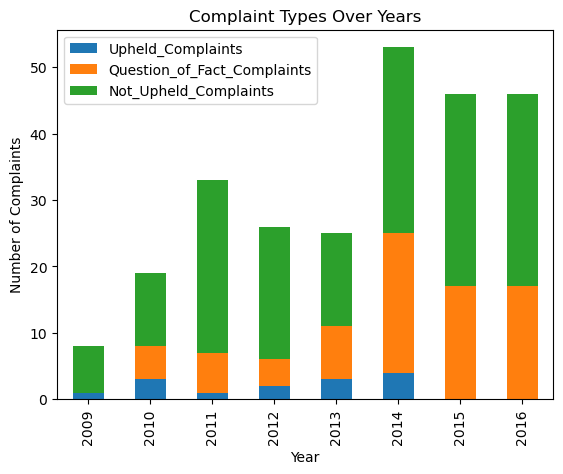

In [7]:
complaints = company_df.groupby('Filing_Year')[[
    'Upheld_Complaints',
    'Question_of_Fact_Complaints',
    'Not_Upheld_Complaints'
]].sum()

# Fill missing years
complaints = complaints.reindex(all_years, fill_value=0)

# Plot
complaints.plot(kind='bar', stacked=True)
plt.title("Complaint Types Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.show()

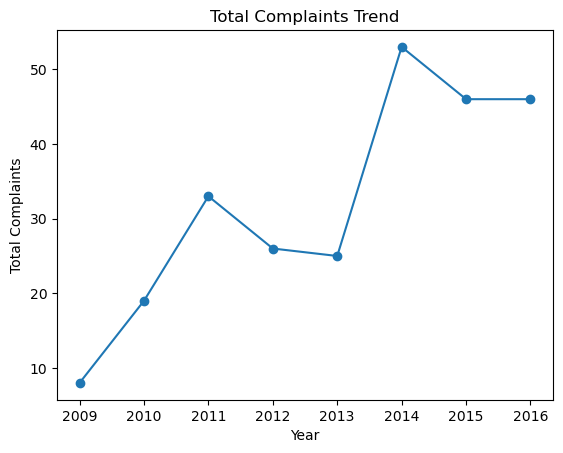

In [8]:
trend = company_df.groupby('Filing_Year')['Total_Complaints'].sum()
trend = trend.reindex(all_years, fill_value=0)

trend.plot(marker='o')
plt.title("Total Complaints Trend")
plt.xlabel("Year")
plt.ylabel("Total Complaints")
plt.show()

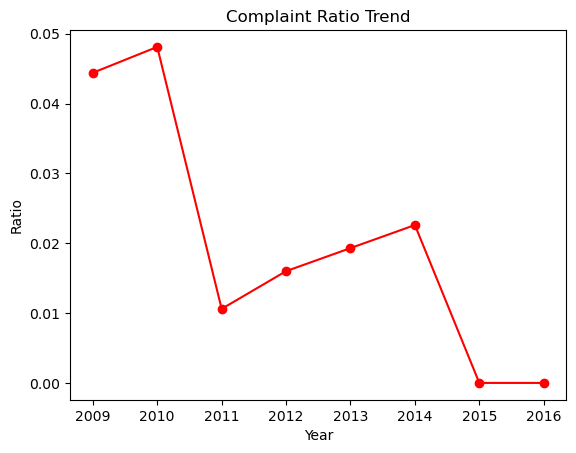

In [9]:
ratio = company_df.groupby('Filing_Year')['Ratio'].mean()
ratio = ratio.reindex(all_years, fill_value=0)

ratio.plot(marker='o', color='red')
plt.title("Complaint Ratio Trend")
plt.xlabel("Year")
plt.ylabel("Ratio")
plt.show()

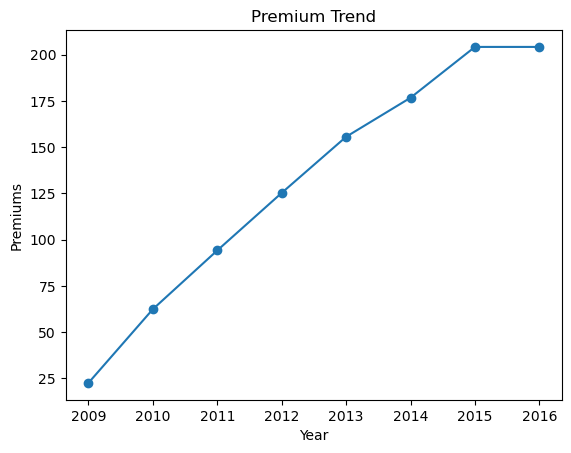

In [10]:
premium = company_df.groupby('Filing_Year')['Premiums_Written'].sum()
premium = premium.reindex(all_years, fill_value=0)

premium.plot(marker='o')
plt.title("Premium Trend")
plt.xlabel("Year")
plt.ylabel("Premiums")
plt.show()

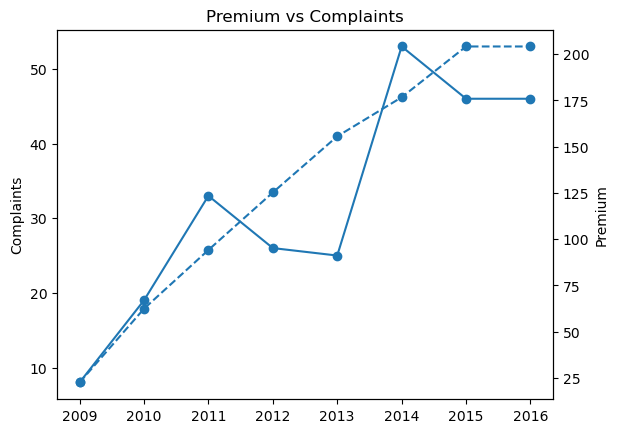

In [11]:
fig, ax1 = plt.subplots()

ax1.plot(trend, marker='o', label='Complaints')
ax1.set_ylabel('Complaints')

ax2 = ax1.twinx()
ax2.plot(premium, linestyle='dashed', marker='o', label='Premium')
ax2.set_ylabel('Premium')

plt.title("Premium vs Complaints")
plt.show()

In [12]:
comparison = df.groupby('Company_Name').agg({
    'Ratio':'mean',
    'Upheld_Complaints':'sum',
    'Total_Complaints':'sum',
    'Premiums_Written':'sum'
}).reset_index()

# Top 5 best companies
best5 = comparison.sort_values(
    ['Ratio','Total_Complaints']
).head(5)

# Top 5 highest complaints
worst5 = comparison.sort_values(
    'Total_Complaints', ascending=False
).head(5)

print("Best Companies:")
print(best5)

print("\nHigh Complaint Companies:")
print(worst5)

Best Companies:
                                      Company_Name  Ratio  Upheld_Complaints  \
30   Amica Property and Casualty Insurance Company    0.0                  0   
84                  Harleysville Insurance Company    0.0                  0   
87        Harleysville Worcester Insurance Company    0.0                  0   
105            Integon Preferred Insurance Company    0.0                  0   
156            Pacific Employers Insurance Company    0.0                  0   

     Total_Complaints  Premiums_Written  
30                  0            10.646  
84                  0            17.453  
87                  0             3.613  
105                 0             9.067  
156                 0             6.768  

High Complaint Companies:
                                       Company_Name     Ratio  \
18                       Allstate Insurance Company  0.088638   
75                  GEICO General Insurance Company  0.012625   
50                   Country-

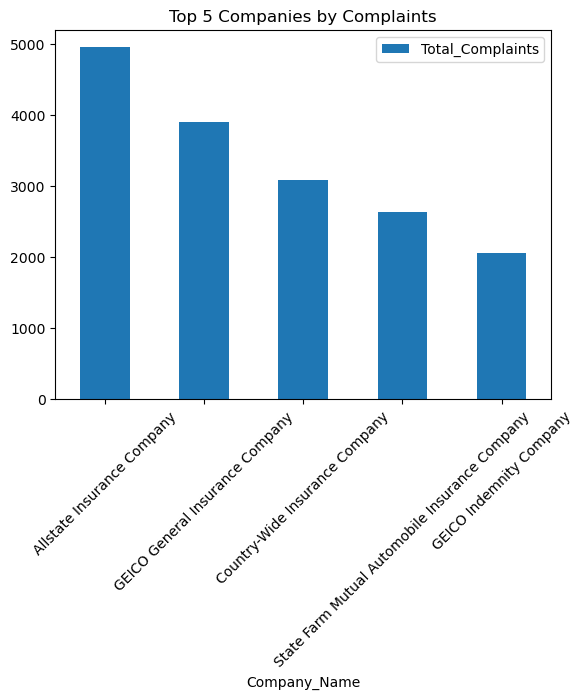

In [13]:
# Top 5 companies by complaints
worst5.plot(x='Company_Name', y='Total_Complaints', kind='bar')
plt.title("Top 5 Companies by Complaints")
plt.xticks(rotation=45)
plt.show()

In [14]:
df.to_csv("insurance_cleaned.csv", index=False)
comparison.to_csv("company_comparison.csv", index=False)

In [15]:
print("Final Selected Company:", company)

print("\nSummary Statistics:")
print(company_df[['Total_Complaints','Premiums_Written','Ratio']].describe())

Final Selected Company: Progressive Specialty Insurance Company

Summary Statistics:
       Total_Complaints  Premiums_Written     Ratio
count          8.000000          8.000000  8.000000
mean          32.000000        130.621500  0.020125
std           15.417986         66.828381  0.018113
min            8.000000         22.534000  0.000000
25%           23.500000         86.218000  0.007950
50%           29.500000        140.419500  0.017650
75%           46.000000        183.567500  0.028050
max           53.000000        204.173000  0.048100
